# Demo 1: Binary Classification with Forest Cover Data

This demo introduces binary classification using the Covertype dataset. The goal is to predict whether a 30x30 meter forest patch contains **Spruce/Fir** or **Lodgepole Pine** based on cartographic features like elevation, slope, and distance to water.

## Learning Objectives

By the end of this demo, you will be able to:

1. Load and explore a large real-world dataset
2. Split data into train/validation/test sets properly
3. Use cross-validation to evaluate model performance
4. Evaluate with confusion matrix, classification report, and ROC curve
5. Train a final model and evaluate on held-out test data

## 0. Setup

In [1]:
%pip install -q scikit-learn matplotlib seaborn pandas numpy

Note: you may need to restart the kernel to use updated packages.


## 1. Load the Covertype Dataset

The Covertype dataset from the UCI ML Repository contains 581k samples with 54 features describing cartographic variables for 30x30 meter cells in Roosevelt National Forest, Colorado. We'll focus on the two most common cover types for a binary classification task.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_covtype

# Load the dataset (may take a moment to download)
print("Loading Covertype dataset...")
data = fetch_covtype()

# Create a DataFrame for easier exploration
df = pd.DataFrame(data.data, columns=data.feature_names)
df['cover_type'] = data.target

# Cover type mapping (from UCI documentation)
cover_types = {
    1: 'Spruce/Fir',
    2: 'Lodgepole Pine',
    3: 'Ponderosa Pine',
    4: 'Cottonwood/Willow',
    5: 'Aspen',
    6: 'Douglas-fir',
    7: 'Krummholz'
}
df['cover_name'] = df['cover_type'].map(cover_types)

print(f"Full dataset shape: {df.shape}")
print(f"\nCover type distribution:")
print(df['cover_name'].value_counts())

# Preview the data
print("\nFirst few rows:")
df[['Elevation', 'Slope', 'Aspect', 'Horizontal_Distance_To_Hydrology', 'cover_name']].head(10)

Loading Covertype dataset...


Full dataset shape: (581012, 56)

Cover type distribution:
cover_name
Lodgepole Pine       283301
Spruce/Fir           211840
Ponderosa Pine        35754
Krummholz             20510
Douglas-fir           17367
Aspen                  9493
Cottonwood/Willow      2747
Name: count, dtype: int64

First few rows:


,Elevation,Slope,Aspect,Horizontal_Distance_To_Hydrology,cover_name
0,2596.0,3.0,51.0,258.0,Aspen
1,2590.0,2.0,56.0,212.0,Aspen
2,2804.0,9.0,139.0,268.0,Lodgepole Pine
3,2785.0,18.0,155.0,242.0,Lodgepole Pine
4,2595.0,2.0,45.0,153.0,Aspen
5,2579.0,6.0,132.0,300.0,Lodgepole Pine
6,2606.0,7.0,45.0,270.0,Aspen
7,2605.0,4.0,49.0,234.0,Aspen
8,2617.0,9.0,45.0,240.0,Aspen
9,2612.0,10.0,59.0,247.0,Aspen


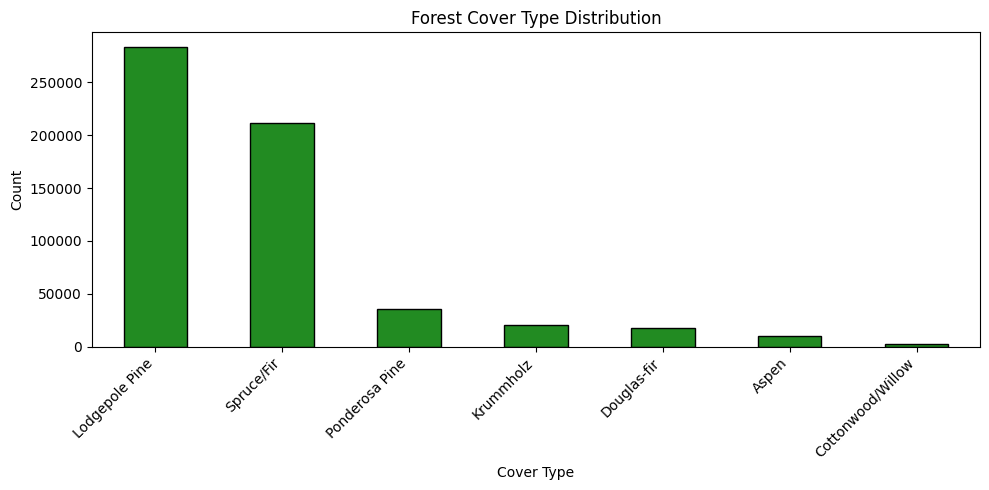

In [3]:
# Visualize the class distribution
plt.figure(figsize=(10, 5))
df['cover_name'].value_counts().plot(kind='bar', color='forestgreen', edgecolor='black')
plt.title('Forest Cover Type Distribution')
plt.xlabel('Cover Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 2. Filter to Binary Classification

For this demo, we'll focus on distinguishing the two most common cover types: Spruce/Fir (1) vs Lodgepole Pine (2). This is still a challenging task with ~495k samples.

In [4]:
# Filter to just the two most common classes
df_binary = df[df['cover_type'].isin([1, 2])].copy()
df_binary['target'] = (df_binary['cover_type'] == 2).astype(int)  # 0=Spruce/Fir, 1=Lodgepole Pine

print(f"Binary dataset shape: {df_binary.shape}")
print(f"\nClass distribution:")
print(df_binary['cover_name'].value_counts())
print(f"\nClass balance: {df_binary['target'].mean():.1%} Lodgepole Pine")

Binary dataset shape: (495141, 57)

Class distribution:
cover_name
Lodgepole Pine    283301
Spruce/Fir        211840
Name: count, dtype: int64

Class balance: 57.2% Lodgepole Pine


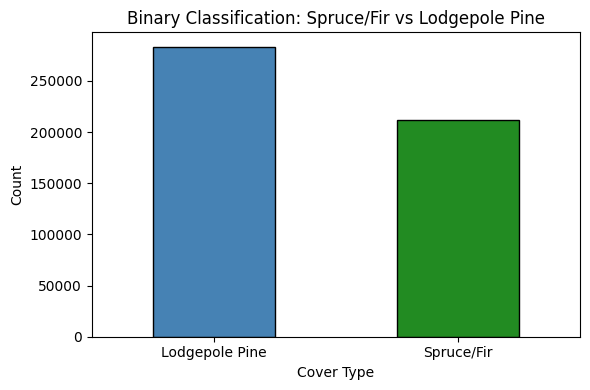


This gives us a 495,141 sample binary classification problem!
Note: Classes are slightly imbalanced (~43% vs ~57%)


In [5]:
# Visualize the binary class split
fig, ax = plt.subplots(figsize=(6, 4))
df_binary['cover_name'].value_counts().plot(kind='bar', color=['steelblue', 'forestgreen'], edgecolor='black', ax=ax)
plt.title('Binary Classification: Spruce/Fir vs Lodgepole Pine')
plt.xlabel('Cover Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"\nThis gives us a {len(df_binary):,} sample binary classification problem!")
print("Note: Classes are slightly imbalanced (~43% vs ~57%)")

## 3. Explore the Data

Understanding feature distributions helps identify which cartographic variables differ between cover types.

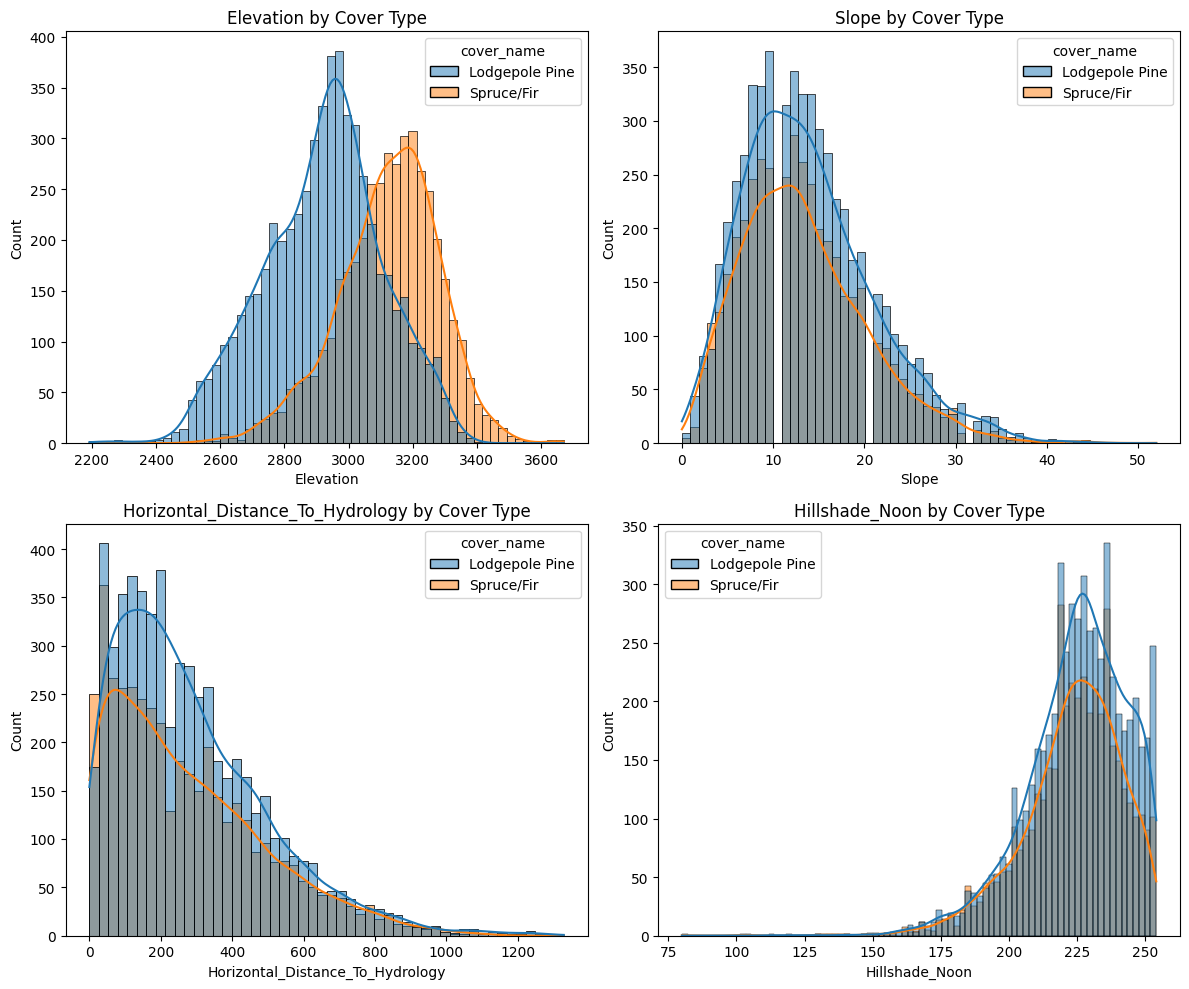

Features most correlated with cover type:
Elevation                             0.506708
Horizontal_Distance_To_Roadways       0.058365
Horizontal_Distance_To_Fire_Points    0.058288
Hillshade_Noon                        0.051035
Hillshade_9am                         0.036679
Vertical_Distance_To_Hydrology        0.032268
Slope                                 0.029987
Horizontal_Distance_To_Hydrology      0.021729
Aspect                                0.018074
Hillshade_3pm                         0.012203
dtype: float64


In [6]:
# Select a few key features to visualize
key_features = ['Elevation', 'Slope', 'Horizontal_Distance_To_Hydrology', 'Hillshade_Noon']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, feature in zip(axes.flat, key_features):
    # Sample for faster plotting
    sample = df_binary.sample(n=10000, random_state=42)
    sns.histplot(data=sample, x=feature, hue='cover_name', kde=True, ax=ax)
    ax.set_title(f'{feature} by Cover Type')
plt.tight_layout()
plt.show()

# Correlation of numeric features with target
numeric_cols = ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
                'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
                'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
                'Horizontal_Distance_To_Fire_Points']
correlations = df_binary[numeric_cols].corrwith(df_binary['target'])
top_features = correlations.abs().sort_values(ascending=False)
print("Features most correlated with cover type:")
print(top_features)

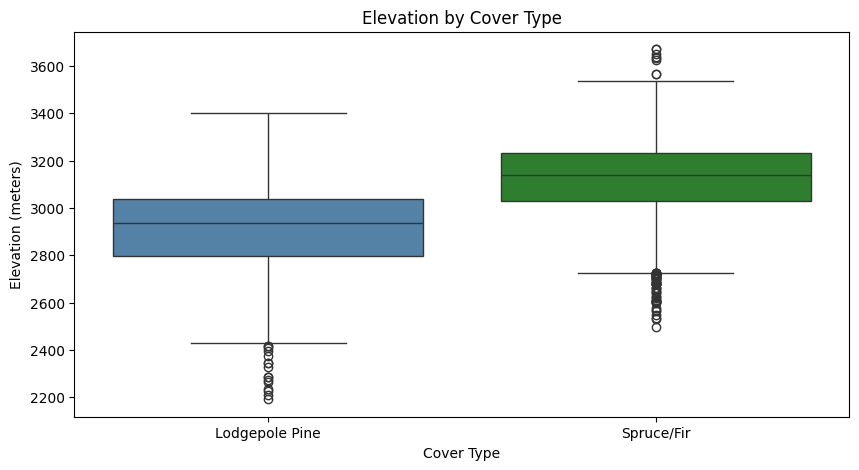

Lodgepole Pine tends to grow at higher elevations than Spruce/Fir
This ecological pattern is what the model will learn to exploit!


In [7]:
# Elevation is the top predictor - let's visualize it
plt.figure(figsize=(10, 5))
sample = df_binary.sample(n=10000, random_state=42)
sns.boxplot(data=sample, x='cover_name', y='Elevation', hue='cover_name', palette=['steelblue', 'forestgreen'], legend=False)
plt.title('Elevation by Cover Type')
plt.xlabel('Cover Type')
plt.ylabel('Elevation (meters)')
plt.show()

print("Lodgepole Pine tends to grow at higher elevations than Spruce/Fir")
print("This ecological pattern is what the model will learn to exploit!")

## 4. Sample and Split Data

With 495k samples, we'll use a smaller sample for faster iteration, then split into train/validation/test sets.

In [8]:
from sklearn.model_selection import train_test_split

# Sample for manageable demo runtime (use full data for production)
df_sample = df_binary.sample(n=50000, random_state=42)

# Separate features and target
X = df_sample.drop(['cover_type', 'cover_name', 'target'], axis=1).values
y = df_sample['target'].values

# First split: hold out 20% as final test set
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train+Validation set: {X_trainval.shape[0]:,} samples (for cross-validation)")
print(f"Test set (final holdout): {X_test.shape[0]:,} samples")
print(f"\nClass distribution in train+val:")
print(f"  Spruce/Fir (0): {sum(y_trainval == 0):,}")
print(f"  Lodgepole Pine (1): {sum(y_trainval == 1):,}")

Train+Validation set: 40,000 samples (for cross-validation)
Test set (final holdout): 10,000 samples

Class distribution in train+val:
  Spruce/Fir (0): 17,111
  Lodgepole Pine (1): 22,889


## 5. Cross-Validation with Logistic Regression

Use stratified k-fold cross-validation to get robust performance estimates before committing to a final model.

In [9]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Create a pipeline that scales features and fits logistic regression
# (Pipeline ensures scaling is done properly within each CV fold)
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Set up stratified k-fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Evaluate with cross-validation
cv_scores = cross_val_score(pipeline, X_trainval, y_trainval, cv=cv, scoring='roc_auc')

print("5-Fold Cross-Validation Results:")
print(f"  AUC per fold: {cv_scores.round(3)}")
print(f"  Mean AUC: {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})")

5-Fold Cross-Validation Results:
  AUC per fold: [0.842 0.847 0.847 0.846 0.848]
  Mean AUC: 0.846 (+/- 0.004)


## 6. Train Final Model

Now that cross-validation gives us confidence in the model, train on the full train+validation set.

In [10]:
# Fit the pipeline on all train+validation data
pipeline.fit(X_trainval, y_trainval)

print("Final model trained on all train+validation data!")
print(f"Training accuracy: {pipeline.score(X_trainval, y_trainval):.4f}")

Final model trained on all train+validation data!
Training accuracy: 0.7728


## 7. Final Evaluation on Test Set

Evaluate on the held-out test set—this is the first and only time we use this data.

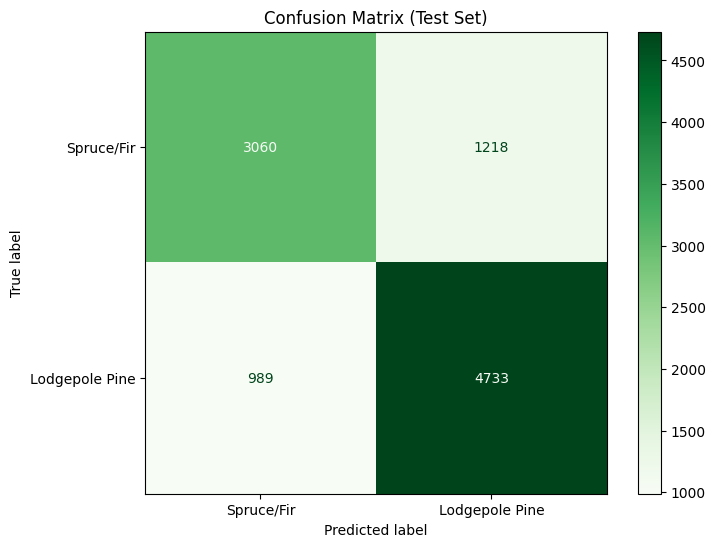


Classification Report (Test Set):
                precision    recall  f1-score   support

    Spruce/Fir       0.76      0.72      0.73      4278
Lodgepole Pine       0.80      0.83      0.81      5722

      accuracy                           0.78     10000
     macro avg       0.78      0.77      0.77     10000
  weighted avg       0.78      0.78      0.78     10000



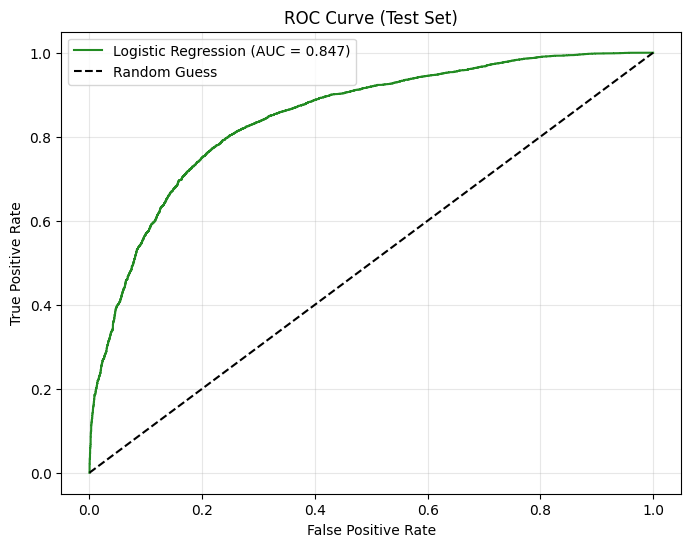


Final Test AUC: 0.8472
Cross-validation AUC was: 0.8462
(These should be similar - if test AUC is much higher, we may have gotten lucky with the split)


In [11]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    ConfusionMatrixDisplay
)

# Make predictions on held-out test set
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Spruce/Fir', 'Lodgepole Pine'])
disp.plot(ax=ax, cmap='Greens')
ax.set_title('Confusion Matrix (Test Set)')
plt.show()

# Classification Report
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred, target_names=['Spruce/Fir', 'Lodgepole Pine']))

# ROC Curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='forestgreen', label=f'Logistic Regression (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Test Set)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nFinal Test AUC: {auc_score:.4f}")
print(f"Cross-validation AUC was: {cv_scores.mean():.4f}")
print("(These should be similar - if test AUC is much higher, we may have gotten lucky with the split)")

## 8. Interpret the Model

Examine which cartographic features are most important for predicting cover type.

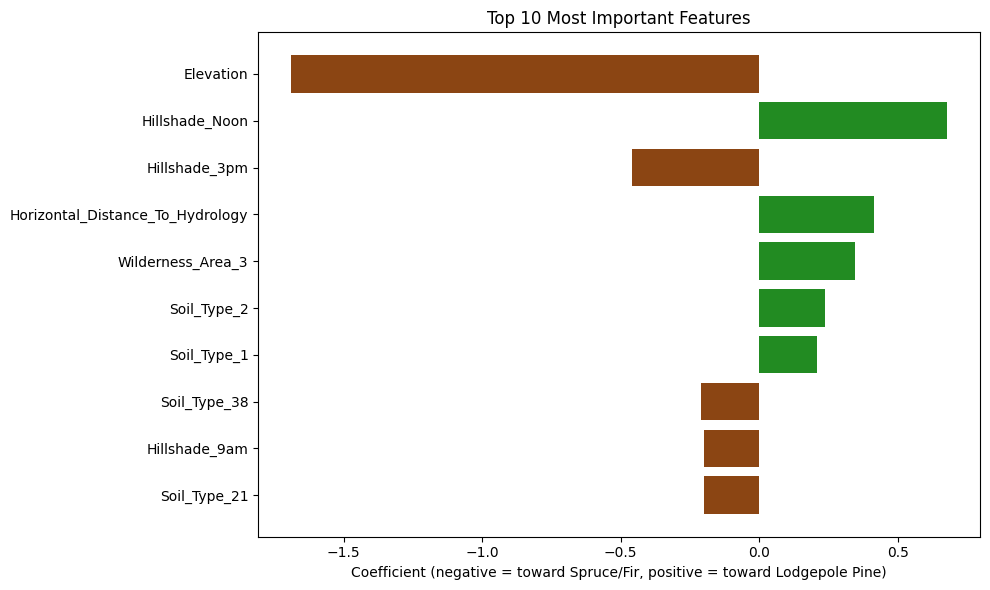


Interpretation:
- Elevation is the strongest predictor - Lodgepole Pine at higher elevations
- Hillshade and aspect features capture sun exposure preferences
- Binary soil type features indicate specific soil associations


In [12]:
# Get feature importances (coefficients) from the trained model
model = pipeline.named_steps['classifier']
feature_names = df_binary.drop(['cover_type', 'cover_name', 'target'], axis=1).columns
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'coefficient': model.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

# Plot top 10 features
plt.figure(figsize=(10, 6))
top_10 = feature_importance.head(10)
colors = ['saddlebrown' if c < 0 else 'forestgreen' for c in top_10['coefficient']]
plt.barh(top_10['feature'], top_10['coefficient'], color=colors)
plt.xlabel('Coefficient (negative = toward Spruce/Fir, positive = toward Lodgepole Pine)')
plt.title('Top 10 Most Important Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- Elevation is the strongest predictor - Lodgepole Pine at higher elevations")
print("- Hillshade and aspect features capture sun exposure preferences")
print("- Binary soil type features indicate specific soil associations")

## Takeaways

- **Cross-validation before final evaluation** - CV gives confidence in model performance before touching the test set
- **Pipeline for proper preprocessing** - putting scaler inside the pipeline prevents data leakage across CV folds
- **Test AUC should match CV AUC** - large discrepancies suggest overfitting or a lucky/unlucky split
- **Large datasets allow sampling** - 50k samples gives reliable estimates; scale up for production
- **Domain features matter** - elevation, sun exposure, and soil type align with ecological knowledge about tree species